# Capstone Project: Optimizing Drug Launch Success with Prescriber Analytics

### IT for Business Data Analytics | MSc | 2025

**Author:** El Mehdi Bayoud  
**Dataset:** Medicare Part D Prescribers - by Provider and Drug + FDA Drug Approvals Database

---

### Objective
To analyze and predict **prescriber adoption patterns** for newly launched drugs, identifying factors that influence early adoption behavior. The goal is to extract insights useful for **pharma launch strategy optimization**.

## 1. Business Problem Definition

### Business Question

Can we predict which prescribers will adopt a new drug within 1 year of launch based on their past prescribing behaviour such as specialty and geography?

In simple terms: can we give a launch team a ranked list of “likely early adopters” for a new drug, before they start prescribing it?

### Why It Matters

Early identification of potential adopters helps pharmaceutical companies to:

- **Optimise marketing spend** by focusing on prescribers with hight potential to adopt.
- **Speed up product uptake** and revenue in the first year after launch, when market share is still open.
- **Inform strategic segmentation and KOL strategy** for future launches by learning which profiles adopt first.

### Analytical Unit and Target Variable

- **Raw unit of analysis:** prescriber–drug–year combination.  
  Each row in the original panel links one prescriber (NPI) to one brand in one calendar year.

- **Modelling unit:** prescriber–drug pair.  
  For each prescriber–drug combination I summarise the panel and define one label.

- **Target variable (`Early_Adopter`):**  
  Early_Adopter = 1 if a prescriber writes at least one prescription for a drug within 12 months of FDA launch; otherwise 0.
This turns the business question into a binary classification problem at prescriber–drug level.

### Index Time and Lookback Window

| Concept                  | Definition                                                                                          |
|--------------------------|------------------------------------------------------------------------------------------------------|
| **Index time**           | The drug’s FDA launch date (`Launch_Year`) – the reference point for measuring adoption.            |
| **Conceptual lookback**  | The 12 months before launch, which defines the information a launch team should be able to see.     |
| **Practical rule**       | For drugs launched between **2018–2020**, I use the calendar year **before launch** as the pre-launch year (`Prelaunch_Year = Launch_Year − 1`), based on Medicare Part D data (available from 2017). |
| **Cutoff rule**          | Only prescribers who are **active in the pre-launch year** (for example, with ≥ at least one total claim (Total_Claims_AllDrugs > 0)) are kept for modelling. |
| **Leak prevention**      | Only information available **before or at launch** is used as features. Variables that depend on post-launch behaviour (e.g. `Adoption_Lag`, `First_Prescription_Year`) are used only to define labels or for EDA, not as predictors. |


### Overview of Analytical Workflow

The project follows a simple step-by-step workflow::

1. **Load and merge data**
2. **Clean and prepare the panel**  
3. **Exploratory analysis (EDA)**  
4. **Feature engineering for modelling (pre-launch only)**  
5. **Feature validation and filtering**  
6. **Modelling and evaluation**  



## **2️. Dataset Description**

### 2.1 Source and Scope
The analysis combines two open datasets:
1. **Medicare Part D Prescribers - by Provider and Drug** – published by the Centers for Medicare & Medicaid Services (CMS).  
   - Annual data on prescription volumes and costs per **prescriber–drug–year** combination.  
   - Time span used: **2017–2023**.  
   - Each yearly file contains ~2–4 GB of data (millions of rows).

2. **FDA Drug Approvals Database** – used to determine each drug’s **launch date (`Launch_Year`)**.  
   - Provides approval year and product type, serving as the *index time* for modeling.

The two datasets are joined by drug identifiers (`Brnd_Name`, `Gnrc_Name`) to align prescriber activity with the correct launch timelines.

---

### 2.2 Data Structure
Each record in the combined dataset represents a **prescriber–drug–year** observation.

| Column                    | Meaning                                                         |
|---------------------------|-----------------------------------------------------------------|
| `Prscrbr_NPI`             | Unique prescriber identifier                                    |
| `Prscrbr_State_Abrvtn`    | Two-letter state abbreviation                                  |
| `Prscrbr_Type`            | Prescriber specialty (e.g. Family Practice, Internal Medicine) |
| `Brnd_Name`, `Gnrc_Name`  | Drug brand and generic names                                   |
| `Tot_Clms`                | Total number of claims for this prescriber–drug–year           |
| `Tot_Drug_Cst`            | Total cost of those claims (USD)                               |
| `Tot_Benes`               | Number of unique beneficiaries                                 |
| `Launch_Year`             | Year of FDA approval (drug launch)                             |
| `First_Prescription_Year` | First observed year the prescriber wrote the drug              |
| `Adoption_Lag`            | Years between `Launch_Year` and `First_Prescription_Year`      |
| `Early_Adopter`           | Binary target: 1 = prescribed within first 12 months of launch |

---

### 2.3 Analytical Goal
Prepare a clean, memory-efficient, **leak-safe** dataset that supports:

- **Exploratory data analysis (EDA)** on prescriber and drug behaviours.  
- **Predictive modelling** of early adoption using **only pre-launch features** (behaviour in the year before launch).

## **3. Data Import & Memory Optimization**

I start by importing all the libraries I need for data cleaning, visualization, and modeling.
Then I load the main Parquet dataset which contains prescriber–drug information for multiple years.
My goal here is just to get the data into memory and check the basic structure to make sure it loaded correctly.

In [ ]:
# --- Installations ---
!pip install -q keras-tuner missingno plotly seaborn matplotlib scikit-learn tensorflow joblib pyarrow fsspec shap optuna catboost duckdb numpy

import duckdb
import gc
# --- Data Manipulation and Analysis ---
import pandas as pd
from pandas.api.types import is_numeric_dtype

import numpy as np

# --- Missing Values Visualization ---
import missingno as msno

# --- Data Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# --- Hyperparameter Optimization ---
import optuna
import optuna.visualization as optuna_vis

# --- Machine Learning (Classical) ---
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

# --- Deep Learning (Neural Networks) ---
import tensorflow as tf
from tensorflow.keras import layers, models

# --- Model Explainability ---
import shap

# --- Persistence, Utilities, Memory Cleanup ---
import joblib
import json
import gc
import psutil

# --- System Settings ---
pd.set_option('display.max_columns', 200)
sns.set_style("whitegrid")


2025-12-02 09:26:43.826098: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-02 09:26:44.161044: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-02 09:26:45.789971: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [ ]:
df = pd.read_parquet("data/PartD.parquet")
print("Dataset loaded:", df.shape)

Dataset loaded: (179028589, 14)


In [ ]:
df.info()          # shows column info
df.describe()      # summary statistics
df.isna().sum()    # count missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179028589 entries, 0 to 179028588
Data columns (total 14 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   Prscrbr_NPI              int32  
 1   Prscrbr_State_Abrvtn     object 
 2   Prscrbr_Type             object 
 3   Brnd_Name                object 
 4   Gnrc_Name                object 
 5   Tot_Clms                 int32  
 6   Tot_Drug_Cst             float64
 7   Tot_Benes                float32
 8   Year                     int16  
 9   Launch_Year              float32
 10  First_Prescription_Year  int16  
 11  Adoption_Lag             float32
 12  Early_Adopter            int8   
 13  Years_Since_Launch       float32
dtypes: float32(4), float64(1), int16(2), int32(2), int8(1), object(4)
memory usage: 11.5+ GB


Prscrbr_NPI                        0
Prscrbr_State_Abrvtn               0
Prscrbr_Type                      85
Brnd_Name                          0
Gnrc_Name                          0
Tot_Clms                           0
Tot_Drug_Cst                       0
Tot_Benes                  103330496
Year                               0
Launch_Year                 65395680
First_Prescription_Year            0
Adoption_Lag                65395680
Early_Adopter                      0
Years_Since_Launch          65395680
dtype: int64

This tells me that my dataset contains 179 million rows and 14 columns

I also noticed that some columns like Tot_Benes, Launch_Year, Adoption_Lag, and Years_Since_Launch have missing values.

Now will handle the missing values in the dataset


## **4. Data Cleaning**


In this step i need to clean the raw dataset to get it more realistic consistent before moving to EDA and modeling.
Remove dups , fix and drop missing rows, trim extreme outliers, and optimise data types.

### 4.1 Duplicate Check and Removal

In [ ]:
# Remove duplicates
dup_count = df.duplicated(subset=["Prscrbr_NPI", "Brnd_Name", "Year"]).sum()
print(f"Duplicates found: {dup_count:,}")
if dup_count > 0:
    df = df.drop_duplicates(subset=["Prscrbr_NPI", "Brnd_Name", "Year"])
print(f"After removing duplicates: {df.shape[0]:,} rows")


Duplicates found: 441,634
After removing duplicates: 178,586,955 rows


### 4.2 Handle Missing Values

In [ ]:
# Quick check before imputing Tot_Benes
print(df["Tot_Benes"].isna().mean(), "share missing in Tot_Benes")
print(df["Tot_Benes"].value_counts(dropna=False).head())


0.5766447890888783 share missing in Tot_Benes
Tot_Benes
NaN     102981237
11.0      6570206
12.0      5657158
13.0      4928515
14.0      4326362
Name: count, dtype: int64


In [ ]:
# Fill missing beneficiaries with 0
df["Tot_Benes"] = df["Tot_Benes"].fillna(0)

# Drop rows with missing core metrics
df = df.dropna(subset=["Tot_Clms", "Tot_Drug_Cst"], how="all")

#drop extreme missing launch data
df = df.dropna(subset=["Launch_Year"])




### 4.3 Logical Consistency Checks

In [ ]:
# Launch year must not exceed observation year
invalid_launch = df[df["Launch_Year"] > df["Year"]]
print(f"Inconsistent Launch_Year > Year: {len(invalid_launch):,} rows")
df = df[df["Launch_Year"] <= df["Year"]]

# Adoption lag cannot be negative
df.loc[df["Adoption_Lag"] < 0, "Adoption_Lag"] = np.nan


Inconsistent Launch_Year > Year: 120,727 rows


### 4.4 Value Range Cleaning / Outlier Trimming

In [ ]:
# Remove negative or unrealistic values
df = df[(df["Tot_Clms"] >= 0) & (df["Tot_Drug_Cst"] >= 0)]

# cap extreme outliers
for col in ["Tot_Clms", "Tot_Drug_Cst"]:
    upper = df[col].quantile(0.999)
    df[col] = np.clip(df[col], 0, upper)



### 4.5 Type Optimization (clean, supervisor-proof)

In [ ]:
# Optimize numeric tupes
num_cols = df.select_dtypes(include="number").columns
df[num_cols] = df[num_cols].apply(pd.to_numeric, downcast="float")

# categorical to category type
cat_cols = ["Prscrbr_NPI", "Brnd_Name", "Prscrbr_Type", "Prscrbr_State_Abrvtn", "Gnrc_Name"]
for c in cat_cols:
    if c in df.columns:
        df[c] = df[c].astype("category")

### 4.6 Post-Cleaning Summary

In [ ]:
print(f"Cleaned dataset shape: {df.shape}")
print("Remaining missing values:")
print(df.isna().sum().sort_values(ascending=False).head(10))
print("Memory usage after cleaning:", round(df.memory_usage(deep=True).sum()/1e9,2), "GB")

Cleaned dataset shape: (113169160, 14)
Remaining missing values:


Adoption_Lag            69408
Prscrbr_Type               57
Prscrbr_State_Abrvtn        0
Brnd_Name                   0
Gnrc_Name                   0
Prscrbr_NPI                 0
Tot_Clms                    0
Tot_Drug_Cst                0
Year                        0
Tot_Benes                   0
dtype: int64
Memory usage after cleaning: 5.92 GB


In [ ]:
# numeric consistency
df["Launch_Year"] = pd.to_numeric(df["Launch_Year"], errors="coerce")
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

# Drop rows missing LaunchYear
df = df.dropna(subset=["Launch_Year"])

# int
df["Launch_Year"] = df["Launch_Year"].astype(int)
df["Year"] = df["Year"].astype(int)

print(f"After cleaning, Launch_Year range: {df['Launch_Year'].min()} → {df['Launch_Year'].max()}")
print(f"After cleaning, Year range: {df['Year'].min()} → {df['Year'].max()}")


After cleaning, Launch_Year range: 1982 → 2023
After cleaning, Year range: 2017 → 2023


- There is almost 442k of duplicates - After removing duplicates: 178,586,955 rows
- About 58% of Tot_benes is missing so i treat as 0 beneficiaries recorded
- I removed cases where lauchYear > Year which was arund 120,727 rows
- Adoption_Lag to NaN becaus a prescriber cannot adopt a drug before launch
- Cap extreme outliers to 0.1% to not take over the models
- Optimised data types
- after cleaning now i have year range from 2017 - 2023



## **5. Feature Engineering (EDA-only)**

  

The objective here is ti create simple variables to describe how fast each prescribers adopts a drug.
>These variables are only used for EDA and not for modeling, its just to help see the patterns of early vs late adoption.

In [ ]:
# Adoption lag
df["Adoption_Lag"] = pd.to_numeric(df["Adoption_Lag"], errors="coerce")
df.loc[df["Adoption_Lag"] < 0, "Adoption_Lag"] = np.nan

# Years since launch
ANALYSIS_YEAR = 2025
df["Years_Since_Launch"] = ANALYSIS_YEAR - df["Launch_Year"]

# Early adopter flag (0–1 years after launch)
df["Early_Adopter"] = df["Adoption_Lag"].apply(
    lambda x: 1 if pd.notnull(x) and 0 <= x <= 1 else 0
)

# Late adopter: very slow adopters
df["Late_Adopter"] = df["Adoption_Lag"].apply(
    lambda x: 1 if pd.notnull(x) and x > 3 else 0
)


* Adoption_Lag : To show how many years it takes after drug launch for a prescriber to presribe it
* Years_Since_Launch : Hw long the drug has been on the market by the analysis year
* Early_Adopter : 1 if the prescriber write the first prescription within 0-1 years after the launch, 0 if not
* Late_Adopter : 1 if the prescriber first prescribes the drug more than 3 years after launch, 0 if not




### **Issues & Fixes Summary Table**


Before modeling, I documented the main data quality issues identified during cleaning and how they were resolved.  
This helps ensure that all transformations are transparent and logically justified.

| **Issue** | **Impact** | **Fix Applied** |
|------------|------------|-----------------|
| `Tot_Benes` missing in ~58% of rows | Would bias patient volume–related features | Imputed as 0 (interpreted as *no recorded beneficiaries*) |
| `Launch_Year` missing for some generic drugs | Prevents adoption timing calculation | Restricted modeling to rows with valid `Launch_Year` |
| `Adoption_Lag < 0` (pre-launch prescriptions) | Logically impossible | Converted to NaN and excluded |
| Dataset extremely large (~179 M rows) | Memory & compute constraints | Optimized dtypes + Parquet compression + grouped sampling |


## **6. Exploratory Data Analysis (EDA)**

Now since the data is clean, Before moving to any predictions, i start by knowing the patterns behinf prescriber behaviour  
The goal of this exploratory phase is to answer questions like:

- How long do prescribers usually wait before trying a new drug?  
- Which specialties or regions are more open to innovation?  
- Do adoption patterns change over time?  


### 6.0 Prepare clean sample for EDA

In [ ]:
con = duckdb.connect()
con.register("df", df)

eda_df = con.execute("""
    SELECT
        Prscrbr_NPI,
        Brnd_Name,
        Launch_Year,
        Prscrbr_Type,
        Prscrbr_State_Abrvtn,
        MIN(Adoption_Lag)  AS Adoption_Lag,
        MAX(Early_Adopter) AS Early_Adopter
    FROM df
    WHERE Launch_Year BETWEEN 2010 AND 2023
    GROUP BY ALL
""").df()

print("EDA base:", eda_df.shape)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

EDA base: (8864273, 7)


In [ ]:
# rows before and after filtering
summary = pd.DataFrame({
    "Stage": ["Original (all years)", "After 2010+ filter", "EDA base (prescriber–drug pairs)"],
    "Row_Count": [
        len(df),
        len(df[df["Launch_Year"] >= 2010]),
        len(eda_df)
    ]
})
display(summary)


,Stage,Row_Count
0,Original (all years),113169160
1,After 2010+ filter,26006298
2,EDA base (prescriber–drug pairs),8864273


In [ ]:
# check number of Early Adopters in the EDA sample
eda_rate = eda_df["Early_Adopter"].mean()
print(f"Early Adopter share in EDA sample: {eda_rate*100:.2f}%")


Early Adopter share in EDA sample: 7.22%


In this step i only kept launches from 2010 to 2023 , and collapse the yearly data into one row for each prescriber-drug now i have EDA base: (8864273, 7).
In this sample Early Adopter share is : 7.22%



### 6.1 Launch-Year Coverage – Prescriber–Drug Pair Density

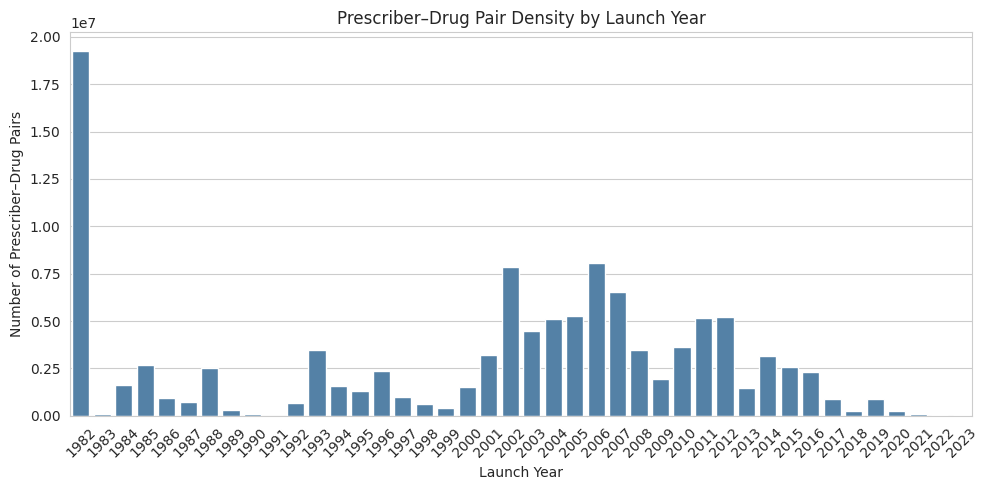

In [ ]:

launch_density = (
    df.groupby("Launch_Year")
      .size()
      .reset_index(name="Pair_Count")
      .query("Launch_Year >= 1980")
)

plt.figure(figsize=(10,5))
sns.barplot(data=launch_density, x="Launch_Year", y="Pair_Count", color="steelblue")
plt.title("Prescriber–Drug Pair Density by Launch Year")
plt.xlabel("Launch Year")
plt.ylabel("Number of Prescriber–Drug Pairs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Most prescriber–drug activity comes from drugs launched between 2000 and 2010, launches after 2017 are fewer.

### 6.2 Distribution of First Prescription Year

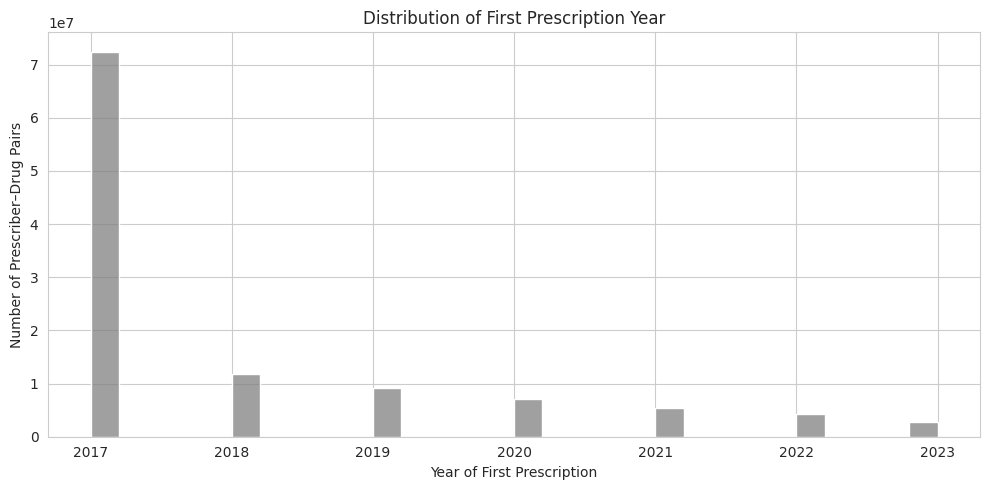

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df["First_Prescription_Year"], bins=30, color="gray")
plt.title("Distribution of First Prescription Year")
plt.xlabel("Year of First Prescription")
plt.ylabel("Number of Prescriber–Drug Pairs")
plt.tight_layout()
plt.show()


Most first prescriptions are between 2017–2019 then the counts slowly go down

The strongest year is 2017, because this the first year of the datset so many of these are just the first ones we can observe.

The drop after 2020 suggest shorter follow up and covid disruption.

### 6.3 Distribution of Adoption Lag


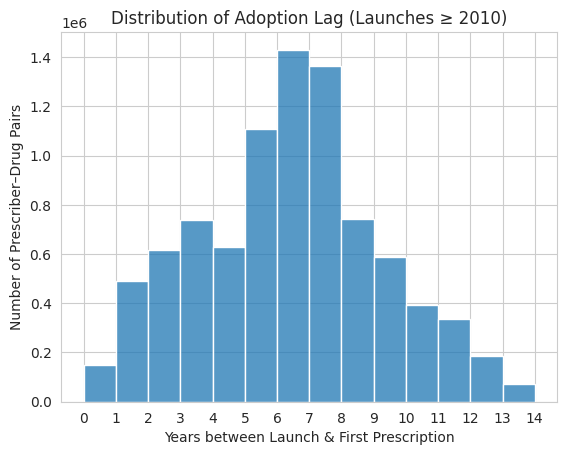

In [ ]:
sns.histplot(eda_df["Adoption_Lag"].dropna(), bins=range(0, 15), kde=False)
plt.xticks(range(0, 15))
plt.title("Distribution of Adoption Lag (Launches ≥ 2010)")
plt.xlabel("Years between Launch & First Prescription")
plt.ylabel("Number of Prescriber–Drug Pairs")
plt.show()

Here most prescriber–drug pairs have an adoption lag 5 and 8 years after launch.
early uptake 0 to 1 years its really small showing that early prescriber are a minority.



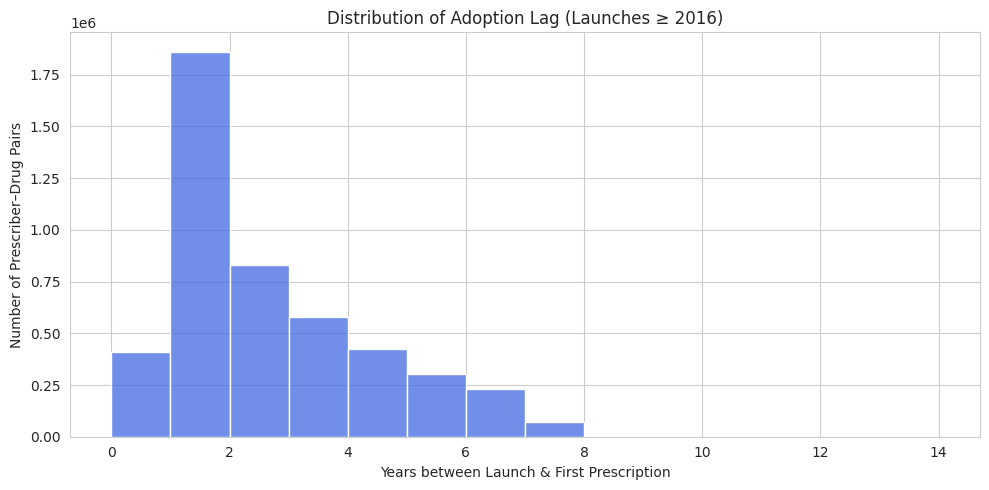

In [ ]:
recent_df = df[df["Launch_Year"] >= 2016].copy()

plt.figure(figsize=(10,5))
sns.histplot(recent_df["Adoption_Lag"].dropna(), bins=range(0, 15), kde=False, color="royalblue")
plt.title("Distribution of Adoption Lag (Launches ≥ 2016)")
plt.xlabel("Years between Launch & First Prescription")
plt.ylabel("Number of Prescriber–Drug Pairs")
plt.tight_layout()
plt.show()

Most of the drung launches from 2016 are picked up really fast, many first ones happend between 1 to 3 years after launch, but for the newest one we still dont see the results yet.

### 6.4 Early Adoption Rate by Specialty
Here, I check which medical specialties are more likely to be early adopters.
This helps reveal which types of doctors usually try new drugs first.

/tmp/ipykernel_350632/1333208021.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  eda_df.groupby("Prscrbr_Type")["Early_Adopter"]


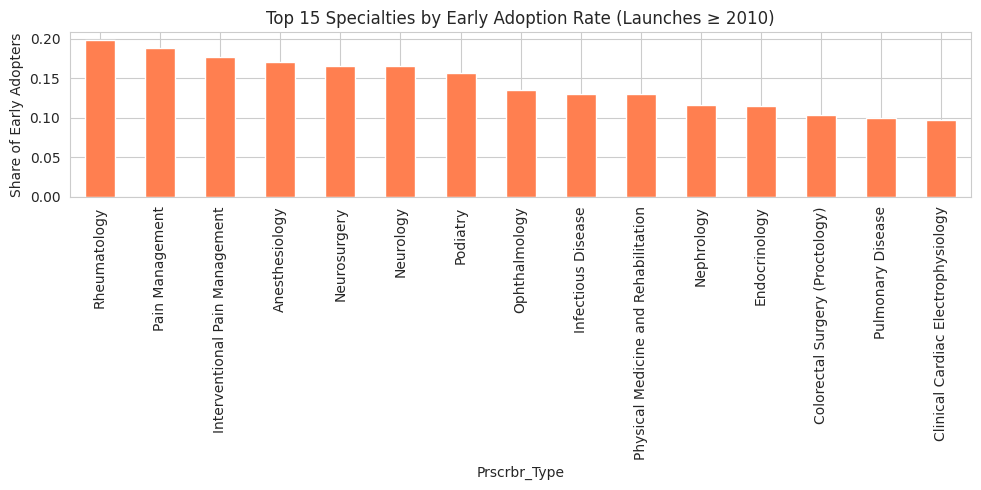

Unique specialties: 222


In [ ]:

adopt_by_type = (
    eda_df.groupby("Prscrbr_Type")["Early_Adopter"]
          .agg(["mean","count"])
          .query("count >= 1000")
          .sort_values("mean", ascending=False)
          .head(15)
)

adopt_by_type["mean"].plot(kind="bar", figsize=(10,5), color="coral")
plt.title("Top 15 Specialties by Early Adoption Rate (Launches ≥ 2010)")
plt.ylabel("Share of Early Adopters")
plt.tight_layout()
plt.show()
print("Unique specialties:", df["Prscrbr_Type"].nunique())

Rheumatology, Pain Management and Interventional Pain Management are at the top, with around 18–20% of their prescriber–drug pairs counted as early adopters.

### 6.5 Launch-Year Exposure by Specialty

/tmp/ipykernel_350632/1494308155.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


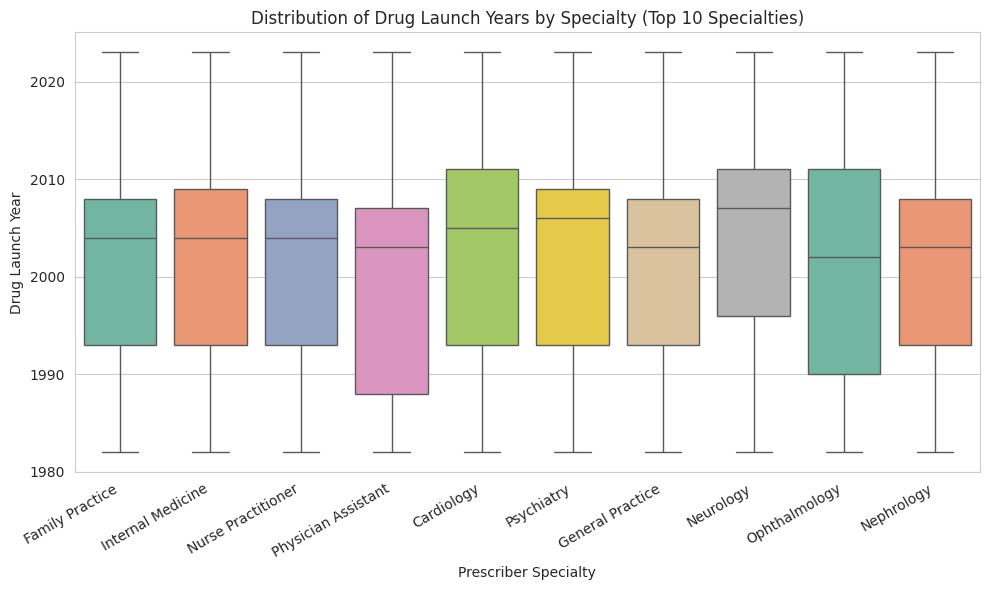

In [ ]:
top_specialties = (
    df["Prscrbr_Type"]
    .value_counts()
    .head(10)
    .index
    .tolist()
)

# --- Subset dataframe before plotting ---
df_top = df[df["Prscrbr_Type"].isin(top_specialties)].copy()

# --- Sort by frequency order for cleaner x-axis ---
df_top["Prscrbr_Type"] = pd.Categorical(
    df_top["Prscrbr_Type"],
    categories=top_specialties,
    ordered=True
)

# --- Plot ---
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_top,
    x="Prscrbr_Type",
    y="Launch_Year",
    palette="Set2"
)
plt.title("Distribution of Drug Launch Years by Specialty (Top 10 Specialties)")
plt.xlabel("Prescriber Specialty")
plt.ylabel("Drug Launch Year")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

- Family Practice, Internal Medicine, General Practice shows a wide spread of launch years.
-Cardiology, Neurology, Ophthalmology have a higher medians and more recent launches, showing that these fields are more exposed to new drugs.


### 6.6 Early Adoption by State
Next, I explore adoption differences by state.
This helps identify where new drugs spread faster geographically.

/tmp/ipykernel_350632/2714006496.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  eda_df.groupby("Prscrbr_State_Abrvtn")["Early_Adopter"]


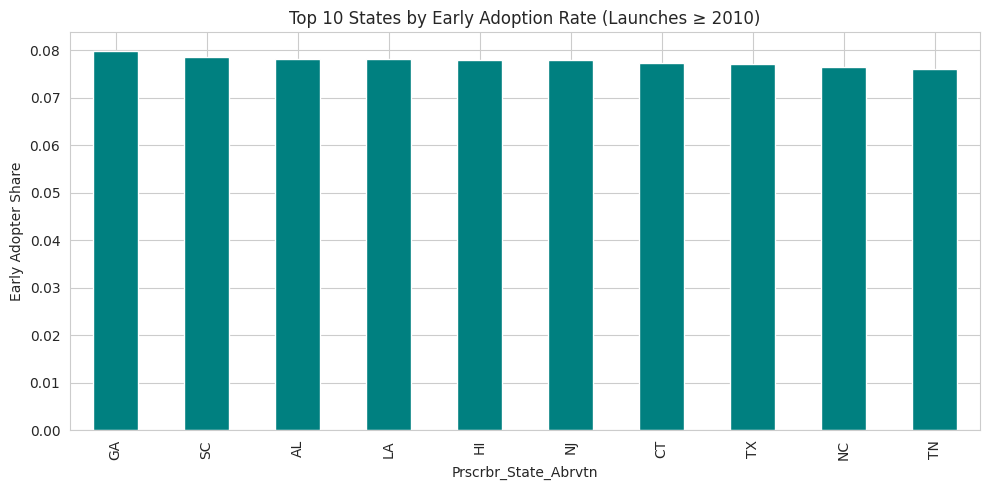

Range of early adoption by state: 0.076–0.080


In [ ]:
adopt_by_state = (
    eda_df.groupby("Prscrbr_State_Abrvtn")["Early_Adopter"]
          .agg(["mean","count"])
          .query("count >= 1000")
          .sort_values("mean", ascending=False)
          .head(10)
)

adopt_by_state["mean"].plot(kind="bar", figsize=(10,5), color="teal")
plt.title("Top 10 States by Early Adoption Rate (Launches ≥ 2010)")
plt.ylabel("Early Adopter Share")
plt.tight_layout()
plt.show()

print(f"Range of early adoption by state: {adopt_by_state['mean'].min():.3f}–{adopt_by_state['mean'].max():.3f}")




> Add blockquote


This shows that there some differences between the states but the the gab its not big, this says that the gegography dosent have a high impact



### 6.7 Correlation Analysis
I use a correlation heatmap to check relationships between numeric features and to detect any multicollinearity before modeling.

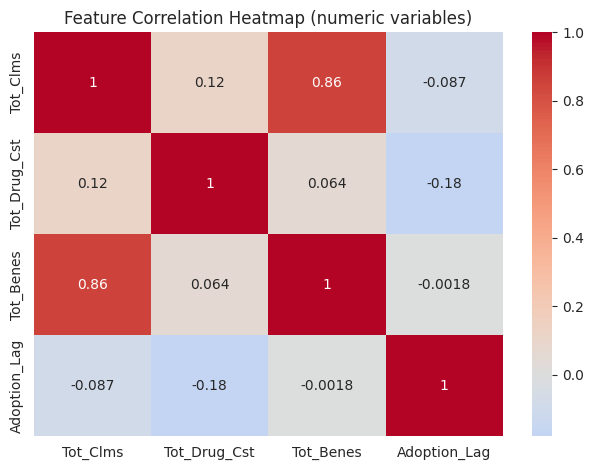

In [ ]:
corr_df = df[["Tot_Clms","Tot_Drug_Cst","Tot_Benes","Adoption_Lag"]].dropna()
sns.heatmap(corr_df.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap (numeric variables)")
plt.tight_layout()
plt.show()


Tot_Clms and Tot_Benes are strongly correlated (0.86): prescribers with more claims treat more patients.

Tot_Drug_Cst is only weakly related to both claims and beneficiaries (0.12 and 0.06)

Adoption_Lag has almost no correlation with any of the three (all close to 0, slightly negative): how early a doctor adopts a drug is basically independent of their volume or cost level.

### 6.8 Claims vs. Drug Cost


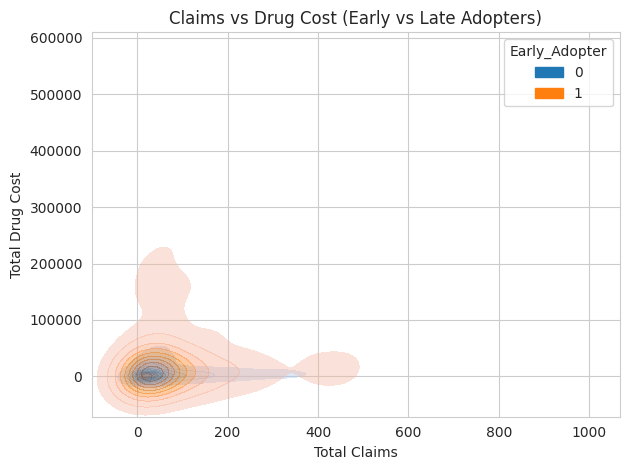

In [ ]:
sns.kdeplot(
    data=df.sample(10000, random_state=42),
    x="Tot_Clms", y="Tot_Drug_Cst",
    hue="Early_Adopter", fill=True, common_norm=False, alpha=0.4
)
plt.title("Claims vs Drug Cost (Early vs Late Adopters)")
plt.xlabel("Total Claims")
plt.ylabel("Total Drug Cost")
plt.tight_layout()
plt.show()


Early adopters are in the middle zone of claims and cost, they are not the biggest prescribers, but also not inactive.
Late adopters have the biggest share.
So early adopters look more like engaged, medium-to-high activity influencers, not the extreme high-volume outliers.

### 6.9 Early Adoption by Launch Cohort

/tmp/ipykernel_350632/346320107.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  modern.groupby("Launch_Cohort")["Early_Adopter"]


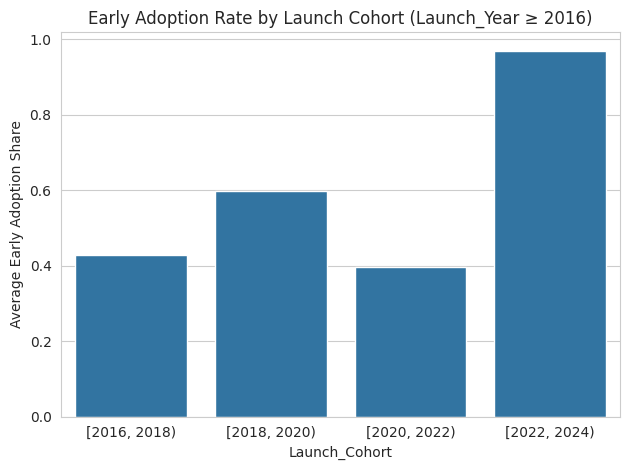

In [ ]:
modern = df[df["Launch_Year"] >= 2016].copy()
bins = [2016, 2018, 2020, 2022, 2024]
modern["Launch_Cohort"] = pd.cut(modern["Launch_Year"], bins=bins, right=False)

cohort_adopt = (
    modern.groupby("Launch_Cohort")["Early_Adopter"]
          .mean()
          .reset_index()
)

sns.barplot(data=cohort_adopt, x="Launch_Cohort", y="Early_Adopter")
plt.title("Early Adoption Rate by Launch Cohort (Launch_Year ≥ 2016)")
plt.ylabel("Average Early Adoption Share")
plt.tight_layout()
plt.show()


For drugs launched 2016–2018 and 2018–2020, early-adoption share is higher.

It drops a bit for the 2020–2022 cohort , we can suggest its related to COVID.

THEN HIGHER for 2022–2024, but we dont see yet the full adoption window for the very newest drugs.

### 6.10 Temporal Effects — Early Adoption Over Time (COVID dip)

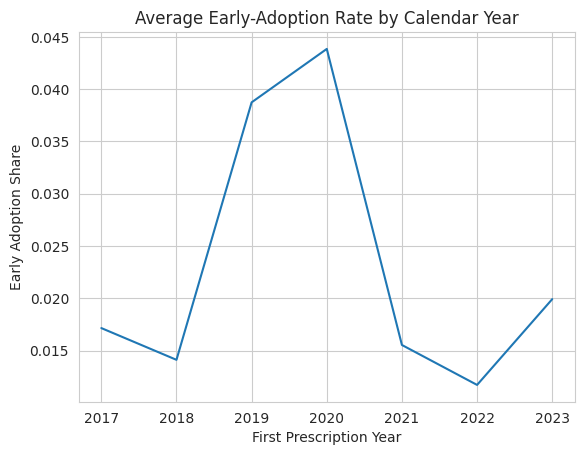

In [ ]:
yearly_adopt = (
    df.groupby("First_Prescription_Year")["Early_Adopter"]
      .mean()
      .reset_index()
)
sns.lineplot(data=yearly_adopt, x="First_Prescription_Year", y="Early_Adopter")
plt.title("Average Early-Adoption Rate by Calendar Year")
plt.xlabel("First Prescription Year")
plt.ylabel("Early Adoption Share")
plt.show()


The average of early adopters is high around 2019–2020, then dropped during 2021–2022 before going up slightly in 2023.
This might be caused by the COVID-19.


### Summary


- Early adoption still rare, between 7 to 8 % showing class imbalance.
- Most activity comes from 2000–2015 launches and 2017–2020 prescription years.
- Early adopters are concentrated in innovation-driven specialties and states.
- Drug cost and claim volume don't strongly explain adoption timing.


## **7. Feature Engineering (for Modeling – leak-free)**

In this Part i build feature engineering for modeling
- A label gives 1 if early adopter or 0 if not
- Features shows how active the prescriber was befor drug launch

### 7.1 Labels at prescriber–drug level

for every (Prscrbr_NPI, Brnd_Name) i take the earliest Adoption_Lag years between launch and first prescription, the first launch year, Prscrbr_Type and Prscrbr_State_Abrvtn

In [ ]:
labels_full = (
    df.groupby(["Prscrbr_NPI", "Brnd_Name"], observed=True)
      .agg(
          Adoption_Lag=("Adoption_Lag", "min"),
          Launch_Year=("Launch_Year", "min"),
          Prscrbr_Type=("Prscrbr_Type", "first"),
          Prscrbr_State_Abrvtn=("Prscrbr_State_Abrvtn", "first"),
      )
      .reset_index()
)

# Early adopter = 1 if first prescription happens within 0–1 years after launch
labels_full["Early_Adopter"] = labels_full["Adoption_Lag"].between(0, 1).astype(int)

print("labels_full:", labels_full.shape)
print("Early adopter rate (all launches):",
      labels_full["Early_Adopter"].mean().round(4))


labels_full: (33984744, 7)
Early adopter rate (all launches): 0.018


### 7.2 Restrict to modern launches and define pre-launch year

- Here i keep only drugs with launch year between 2018 and 2020
- I create: Prelaunch_Year = Launch_Year − 1 means that i take the prescriber behaviour in 2018 for a drug launched in 2019

In [ ]:
# keep only recent drugs where a 1-year pre-launch window exists in Part D
labels = labels_full[labels_full["Launch_Year"].between(2018, 2020)].copy()
labels["Prelaunch_Year"] = labels["Launch_Year"] - 1

print("labels (2018–2020 launches):", labels.shape)
print("Early adopter rate (2018–2020):",
      labels["Early_Adopter"].mean().round(4))
print(labels[["Launch_Year", "Prelaunch_Year"]].drop_duplicates().head())

labels (2018–2020 launches): (625515, 8)
Early adopter rate (2018–2020): 0.389
     Launch_Year  Prelaunch_Year
34          2018            2017
49          2019            2018
313         2020            2019


### 7.3 Prescriber–year baseline (across all drugs)

here for every (Prscrbr_NPI, Year) i calculate how many claims in that year, total coast, how many beneficiaires, unique drugs, unique generics

In [ ]:
presc_year = (
    df.groupby(["Prscrbr_NPI", "Year"], observed=True)
      .agg(
          Total_Claims_AllDrugs=("Tot_Clms", "sum"),
          Total_Cost_AllDrugs=("Tot_Drug_Cst", "sum"),
          Total_Benes_AllDrugs=("Tot_Benes", "sum"),
          Unique_Drugs_Year=("Brnd_Name", "nunique"),
          Unique_Generics_Year=("Gnrc_Name", "nunique"),
      )
      .reset_index()
)

print("presc_year:", presc_year.shape)
display(presc_year.head())


presc_year: (6526910, 7)


,Prscrbr_NPI,Year,Total_Claims_AllDrugs,Total_Cost_AllDrugs,Total_Benes_AllDrugs,Unique_Drugs_Year,Unique_Generics_Year
0,1003000126,2017,294.0,11400.45,180.0,12,12
1,1003000126,2018,238.0,8007.17,132.0,13,13
2,1003000126,2019,266.0,9171.21,145.0,14,14
3,1003000126,2020,84.0,5583.70,14.0,5,5
4,1003000126,2021,570.0,37694.06,389.0,21,21


### 7.4 Merge labels with pre-launch behaviour

here i join thetwo tables labels and behaviour, now each presriber-drug pair gets the prescriber activity in the year before launch.

In [ ]:
model_df = labels.merge(
    presc_year,
    left_on=["Prscrbr_NPI", "Prelaunch_Year"],
    right_on=["Prscrbr_NPI", "Year"],
    how="left",
    validate="many_to_one",
)


model_df = model_df.drop(columns=["Year"])

model_df = model_df.rename(
    columns={
        "Unique_Drugs_Year": "Unique_Drugs_Prelaunch",
        "Unique_Generics_Year": "Unique_Generics_Prelaunch",
    }
)

print("model_df before filtering:", model_df.shape)
print("Share with non-missing pre-launch claims:",
      model_df["Total_Claims_AllDrugs"].notna().mean().round(3))
print("Early-Adopter ratio (before filtering):",
      model_df["Early_Adopter"].mean().round(4))

model_df before filtering: (625515, 13)
Share with non-missing pre-launch claims: 0.856
Early-Adopter ratio (before filtering): 0.389


### 7.5 Keep only prescribers active in the pre-launch year

Here i simply drop prescribers who are inactive in the pre-launch year.

In [ ]:
active_mask = model_df["Total_Claims_AllDrugs"].fillna(0) > 0
model_df = model_df[active_mask].copy()

print("model_df after restricting to active pre-launch prescribers:",
      model_df.shape)
print("Early-Adopter ratio (active prescribers):",
      model_df["Early_Adopter"].mean().round(4))

model_df after restricting to active pre-launch prescribers: (535417, 13)
Early-Adopter ratio (active prescribers): 0.4315


### 7.6 Final cleaning and dtypes

In [ ]:
numeric_features = [
    "Total_Claims_AllDrugs",
    "Total_Cost_AllDrugs",
    "Total_Benes_AllDrugs",
    "Unique_Drugs_Prelaunch",
    "Unique_Generics_Prelaunch",
]

for col in numeric_features:
    if col in model_df.columns:
        model_df[col] = model_df[col].fillna(0)

cat_cols = ["Prscrbr_Type", "Prscrbr_State_Abrvtn"]
for col in cat_cols:
    if col in model_df.columns:
        model_df[col] = (
            model_df[col]
            .astype("string")
            .fillna("Unknown")
            .astype("category")
        )


for col in numeric_features:
    if col in model_df.columns and is_numeric_dtype(model_df[col]):
        model_df[col] = pd.to_numeric(model_df[col], downcast="float")

gc.collect()

print("\nFinal modeling frame:", model_df.shape)
print("Early-Adopter ratio:", model_df["Early_Adopter"].mean().round(4))
print("Unique specialties:", model_df["Prscrbr_Type"].nunique())
print("Unique states:", model_df["Prscrbr_State_Abrvtn"].nunique())

print("\nNumeric summary (first 10 rows):")
display(model_df.select_dtypes(include="number").describe().T.head(10))


Final modeling frame: (535417, 13)
Early-Adopter ratio: 0.4315
Unique specialties: 116
Unique states: 59

Numeric summary (first 10 rows):


,count,mean,std,min,25%,50%,75%,max
Adoption_Lag,512115.0,1.918924,1.373876,0.00,1.0,2.00,3.00,5.000000e+00
Launch_Year,535417.0,2019.061137,0.633002,2018.00,2019.0,2019.00,2019.00,2.020000e+03
Early_Adopter,535417.0,0.431484,0.495284,0.00,0.0,0.00,1.00,1.000000e+00
Prelaunch_Year,535417.0,2018.061137,0.633002,2017.00,2018.0,2018.00,2018.00,2.019000e+03
Total_Claims_AllDrugs,535417.0,3359.190918,4637.202637,11.00,550.0,1723.00,4404.00,1.031470e+05
Total_Cost_AllDrugs,535417.0,353720.459474,549712.351028,8.71,47445.3,173995.21,419446.46,1.084974e+07
Total_Benes_AllDrugs,535417.0,766.312683,1033.530396,0.00,114.0,398.00,1054.00,2.926100e+04
Unique_Drugs_Prelaunch,535417.0,47.469154,41.300900,1.00,15.0,35.00,72.00,3.500000e+02
Unique_Generics_Prelaunch,535417.0,45.431019,39.114742,1.00,14.0,33.00,69.00,3.200000e+02



## **8. Feature Validation and Modeling Readiness**

### 8.1 Objective

In this section i check if the pre-launch features are ready for modeling.



### 8.2 Numeric Feature EDA

Here I focus on these numeric features from the year before launch:

Total_Claims_AllDrugs, Total_Cost_AllDrugs, Total_Benes_AllDrugs, Unique_Drugs_Prelaunch, Unique_Generics_Prelaunch

I look at summary stats, skewness, and histograms on a sample.


Numeric features used: ['Total_Claims_AllDrugs', 'Total_Cost_AllDrugs', 'Total_Benes_AllDrugs', 'Unique_Drugs_Prelaunch', 'Unique_Generics_Prelaunch']


,count,mean,std,min,25%,50%,75%,max
Total_Claims_AllDrugs,535417.0,3359.190918,4637.202637,11.00,550.0,1723.00,4404.00,1.031470e+05
Total_Cost_AllDrugs,535417.0,353720.459474,549712.351028,8.71,47445.3,173995.21,419446.46,1.084974e+07
Total_Benes_AllDrugs,535417.0,766.312683,1033.530396,0.00,114.0,398.00,1054.00,2.926100e+04
Unique_Drugs_Prelaunch,535417.0,47.469154,41.300900,1.00,15.0,35.00,72.00,3.500000e+02
Unique_Generics_Prelaunch,535417.0,45.431019,39.114742,1.00,14.0,33.00,69.00,3.200000e+02



Skewness per numeric feature:


Total_Cost_AllDrugs          4.100929
Total_Benes_AllDrugs         3.961976
Total_Claims_AllDrugs        3.684116
Unique_Drugs_Prelaunch       1.230121
Unique_Generics_Prelaunch    1.166916
dtype: float64

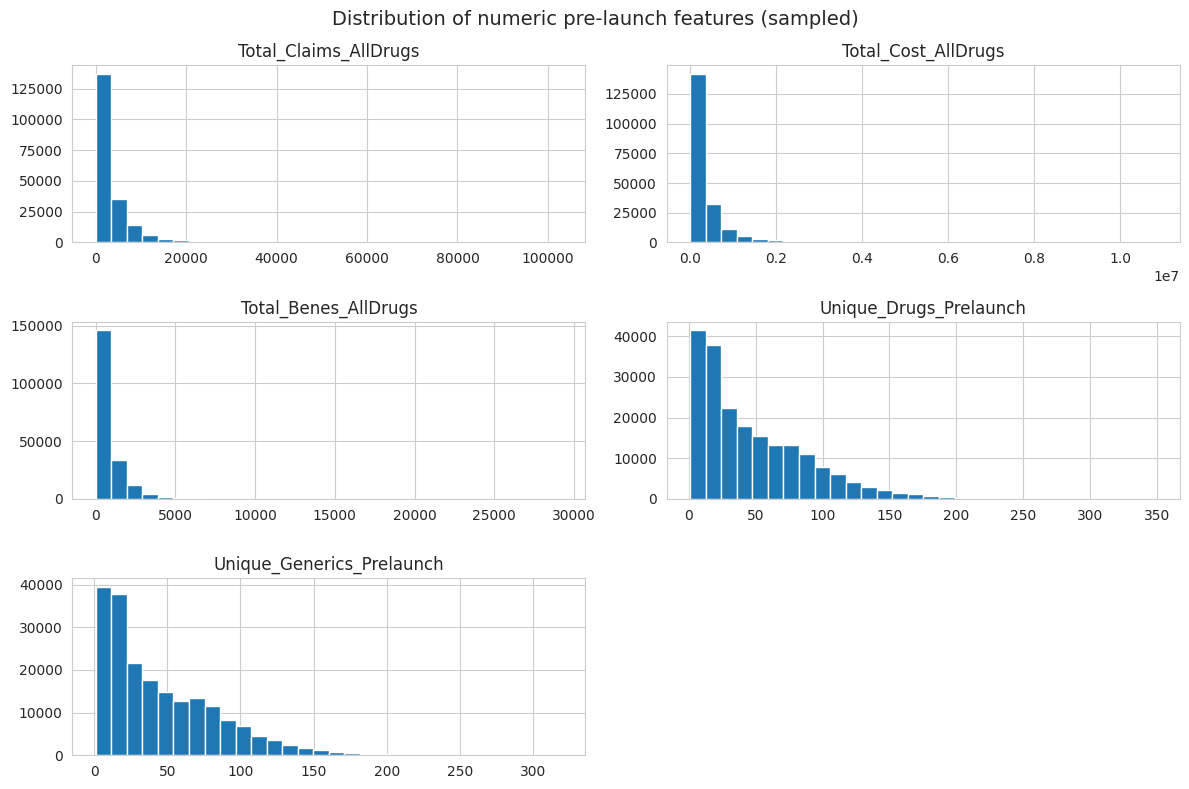

In [ ]:
numeric_features = [
    "Total_Claims_AllDrugs",
    "Total_Cost_AllDrugs",
    "Total_Benes_AllDrugs",
    "Unique_Drugs_Prelaunch",
    "Unique_Generics_Prelaunch",
]

# Keep only those that actually exist (defensive)
numeric_features = [c for c in numeric_features if c in model_df.columns]
print("\nNumeric features used:", numeric_features)

# Summary statistics
num_summary = model_df[numeric_features].describe().T
display(num_summary)

# Skewness
print("\nSkewness per numeric feature:")
skew_vals = model_df[numeric_features].skew(numeric_only=True).sort_values(ascending=False)
display(skew_vals)

# Simple histograms on a sample (to avoid heavy plots)
plot_sample = model_df[numeric_features].sample(
    min(200_000, len(model_df)), random_state=42
)
plot_sample.hist(bins=30, figsize=(12, 8))
plt.suptitle("Distribution of numeric pre-launch features (sampled)", fontsize=14)
plt.tight_layout()
plt.show()

### 8.3 Optional Log-Transform Check

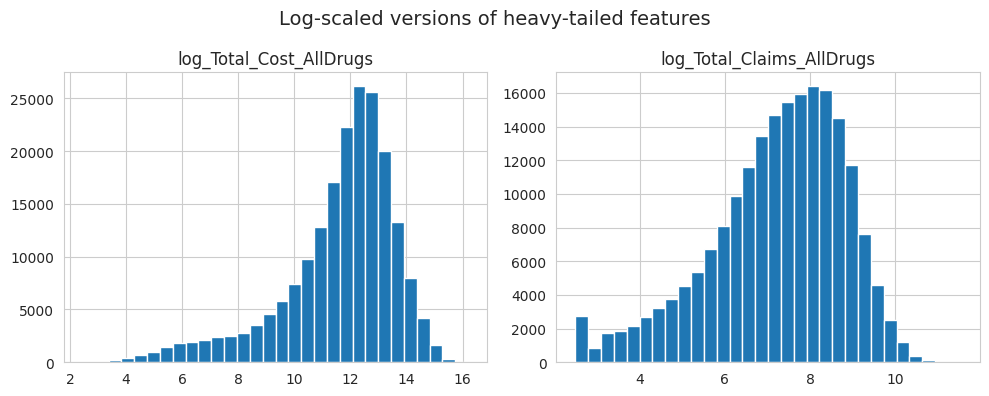

In [ ]:
eda_tmp = model_df[numeric_features].copy()

log_cols = [c for c in ["Total_Cost_AllDrugs", "Total_Claims_AllDrugs"] if c in eda_tmp.columns]

for col in log_cols:
    eda_tmp[f"log_{col}"] = np.log1p(eda_tmp[col])

if log_cols:
    plot_log = eda_tmp[[f"log_{c}" for c in log_cols]].sample(
        min(200_000, len(eda_tmp)), random_state=42
    )
    plot_log.hist(bins=30, figsize=(10, 4))
    plt.suptitle("Log-scaled versions of heavy-tailed features", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("No log-columns to plot.")

### 8.4 Pre-launch Activity Diagnostics

Here i see what the pre launch activity means in practice

In [ ]:
print("\nQuick view of claims and portfolio size (head):")
display(
    model_df[
        ["Total_Claims_AllDrugs", "Total_Cost_AllDrugs",
         "Total_Benes_AllDrugs", "Unique_Drugs_Prelaunch",
         "Unique_Generics_Prelaunch"]
    ].head()
)



Quick view of claims and portfolio size (head):


,Total_Claims_AllDrugs,Total_Cost_AllDrugs,Total_Benes_AllDrugs,Unique_Drugs_Prelaunch,Unique_Generics_Prelaunch
0,814.0,90076.95,176.0,9.0,9.0
1,705.0,70226.60,186.0,8.0,8.0
2,4753.0,209311.45,808.0,77.0,74.0
3,4753.0,209311.45,808.0,77.0,74.0
4,4753.0,209311.45,808.0,77.0,74.0


### 8.5 Categorical Cardinality Check

Here i check the two  categorical features:
- Prscrbr_Type - prescriber specialty
- Prscrbr_State_Abrvtn - state

One-hot encoding would create too many columns and make the model heavy, so CatBoost or target encoding are better choices.

In [ ]:
cat_cols = ["Prscrbr_Type", "Prscrbr_State_Abrvtn"]
cat_cols = [c for c in cat_cols if c in model_df.columns]

print("\nCategorical features and their cardinality:")
for c in cat_cols:
    print(f"- {c}: {model_df[c].nunique()} unique values")
    display(model_df[c].value_counts().head())


Categorical features and their cardinality:
- Prscrbr_Type: 116 unique values


Prscrbr_Type
Family Practice        116519
Internal Medicine      109439
Nurse Practitioner      72515
Physician Assistant     31776
Neurology               28466
Name: count, dtype: int64

- Prscrbr_State_Abrvtn: 59 unique values


Prscrbr_State_Abrvtn
CA    54993
NY    39097
FL    37145
TX    35924
PA    25490
Name: count, dtype: int64

### 8.6 Business View by Early-Adopter Flag

Here i build a small business sanity table

In [ ]:
business_view = (
    model_df.groupby("Early_Adopter")[
        ["Total_Claims_AllDrugs", "Total_Cost_AllDrugs",
         "Total_Benes_AllDrugs", "Unique_Drugs_Prelaunch",
         "Unique_Generics_Prelaunch"]
    ]
    .mean()
    .round(1)
)
print("\nAverage pre-launch activity by Early_Adopter flag:")
display(business_view)


Average pre-launch activity by Early_Adopter flag:


,Total_Claims_AllDrugs,Total_Cost_AllDrugs,Total_Benes_AllDrugs,Unique_Drugs_Prelaunch,Unique_Generics_Prelaunch
Early_Adopter,,,,,
0,3049.100098,322615.7,700.400024,43.200001,41.400002
1,3767.800049,394703.5,853.099976,53.000000,50.700001


## **9. MODELING: Predicting Early Adoption**

### 9.1 Objective

The chapter shows how I turned the cleaned dataset into working machine-learning models. The focus is on how I built the modelling frame, how I split the data in a time-honest way, how I handled class imbalance, and how I trained and tuned three tree-based models (Random Forest, HistGradientBoosting, CatBoost). I also explain the evaluation measures and how I have chosen and interpreted the final model.

In practice this pipeline is supposed to be reusable. If a new drug would be launched, the launch team would develop the same type of pre-launch features for the target prescribers, and then use the trained model to obtain a ranked list of likely early adopters. The idea is not only to create a model that will be applicable to my sample, but to have a clear flow of steps (data frame → split → train → evaluate → interpret) that can be repeated to future launches in the same manner.

The modelling step is used to predict Early_Adopter for each prescriber-drug pair, only with pre-launch features. All features come from the 12-month baseline window before launch (or its 2017 proxy), and the label tells me if the prescriber wrote at least one prescription in the first 12 months after launch of that specific drug.

The modelling frame is restricted to the launched drugs in the period between 2018 and 2020, and prescribers who are active in the baseline year for example with at least one total claim across all drugs (Total_Claims_AllDrugs > 0). This keeps the focus on new launches and does not have very old products where the adoption story is different.


### 9.2 Feature sets (NO one-hot)

From this modeling frame I use these features:

Numeric features (pre-launch year, all drugs): Total_Claims_AllDrugs, Total_Cost_AllDrugs, Total_Benes_AllDrugs, Unique_Drugs_Prelaunch, Unique_Generics_Prelaunch

Categorical features: Prscrbr_Type (specialty), Prscrbr_State_Abrvtn (state)

Filled the missing values with 0 and convert them to floats, convert the categorical features into strings, filling missing values with ‘Unknown’ and convert them to categorical types.
All the post-launch information were not used as feature, the fields like adoption-lag, early-adopter, and launch-year are only used for labels, time logic and evaluation and not as inputs to the models.

This makes the feature set leak free and in line with the pre-launch decision.


In [ ]:

numeric_features = [
    "Total_Claims_AllDrugs",
    "Total_Cost_AllDrugs",
    "Total_Benes_AllDrugs",
    "Unique_Drugs_Prelaunch",
    "Unique_Generics_Prelaunch",

]
categorical_features = ["Prscrbr_Type", "Prscrbr_State_Abrvtn"]

target_col = "Early_Adopter"
id_cols = ["Prscrbr_NPI", "Brnd_Name"]

# Safe fills
for c in numeric_features:
    if c in model_df.columns:
        model_df[c] = model_df[c].fillna(0)

for c in categorical_features:
    if c in model_df.columns:
        model_df[c] = (
            model_df[c]
            .astype("string")
            .fillna("Unknown")
            .astype("category")
        )

print("Final modeling frame:", model_df.shape)
print("Early-Adopter ratio:", model_df[target_col].mean().round(4))
print("Unique specialties:", model_df["Prscrbr_Type"].nunique())
print("Unique states:", model_df["Prscrbr_State_Abrvtn"].nunique())

display(model_df.select_dtypes(include="number").describe().T.head(10))

Final modeling frame: (535417, 13)
Early-Adopter ratio: 0.4315
Unique specialties: 116
Unique states: 59


,count,mean,std,min,25%,50%,75%,max
Adoption_Lag,512115.0,1.918924,1.373876,0.00,1.0,2.00,3.00,5.000000e+00
Launch_Year,535417.0,2019.061137,0.633002,2018.00,2019.0,2019.00,2019.00,2.020000e+03
Early_Adopter,535417.0,0.431484,0.495284,0.00,0.0,0.00,1.00,1.000000e+00
Prelaunch_Year,535417.0,2018.061137,0.633002,2017.00,2018.0,2018.00,2018.00,2.019000e+03
Total_Claims_AllDrugs,535417.0,3359.190918,4637.202637,11.00,550.0,1723.00,4404.00,1.031470e+05
Total_Cost_AllDrugs,535417.0,353720.459474,549712.351028,8.71,47445.3,173995.21,419446.46,1.084974e+07
Total_Benes_AllDrugs,535417.0,766.312683,1033.530396,0.00,114.0,398.00,1054.00,2.926100e+04
Unique_Drugs_Prelaunch,535417.0,47.469154,41.300900,1.00,15.0,35.00,72.00,3.500000e+02
Unique_Generics_Prelaunch,535417.0,45.431019,39.114742,1.00,14.0,33.00,69.00,3.200000e+02


### 9.3 Time-safe split by Launch_Year

- this split means that the models only act from older launches and testedon newer ones :

Train set: drugs with Launch_Year ≤ 2019 ;
Test set: drugs with Launch_Year = 2020


In [ ]:

train_df = model_df[model_df["Launch_Year"] <= 2019].copy()
test_df  = model_df[model_df["Launch_Year"] == 2020].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Train Early-Adopter rate:", train_df[target_col].mean().round(4))
print("Test Early-Adopter rate:", test_df[target_col].mean().round(4))

# Numeric views
X_train_num = train_df[numeric_features].copy()
X_test_num  = test_df[numeric_features].copy()

y_train = train_df[target_col].astype(int).values
y_test  = test_df[target_col].astype(int).values

# For CatBoost: numeric + categoricals
X_train_cb = train_df[numeric_features + categorical_features].copy()
X_test_cb  = test_df[numeric_features + categorical_features].copy()
cat_idx = [X_train_cb.columns.get_loc(c) for c in categorical_features]


Train shape: (410781, 14)
Test shape: (124636, 14)
Train Early-Adopter rate: 0.4805
Test Early-Adopter rate: 0.2701


### 9.4 Imbalance handling

Even in this filtered sample, early adopters are not the majority.
To avoid the model focusing only on the 0-class, I use class weights


In [ ]:

classes = np.array([0, 1])
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
cw_dict = {0: class_weights[0], 1: class_weights[1]}
print("Class weights:", cw_dict)


Class weights: {0: 0.9623995501721997, 1: 1.0406579654043757}


### 9.5 Sampling and validation split

To make Optuna fast i allow max rows of 2 millions in the tuning sample, stratified_fast_sample keeps all positive cases then samples negatives to kepp a stable class ratio.
then i create a train validation split on the traing data.

In [ ]:


def stratified_fast_sample(X, y, max_rows=2_000_000, random_state=42):
    n = len(y)
    if n <= max_rows:
        return X, y

    pos_idx = np.where(y == 1)[0]
    neg_idx = np.where(y == 0)[0]

    rng = np.random.RandomState(random_state)
    pos_keep = len(pos_idx)
    rem = max_rows - pos_keep

    if rem <= 0:
        pick_pos = rng.choice(pos_idx, size=max_rows, replace=False)
        return X.iloc[pick_pos], y[pick_pos]

    neg_keep = min(rem, len(neg_idx))
    pick_neg = rng.choice(neg_idx, size=neg_keep, replace=False)
    keep_idx = np.concatenate([pos_idx, pick_neg])
    rng.shuffle(keep_idx)

    return X.iloc[keep_idx], y[keep_idx]

# for you, this will probably keep everything (train < 2M anyway)
X_train_num_fast, y_train_fast = stratified_fast_sample(
    X_train_num, y_train, max_rows=2_000_000, random_state=42
)
X_train_cb_fast = X_train_cb.loc[X_train_num_fast.index]

from sklearn.model_selection import train_test_split

X_tr_num, X_val_num, y_tr, y_val = train_test_split(
    X_train_num_fast,
    y_train_fast,
    test_size=0.15,
    stratify=y_train_fast,
    random_state=42,
)
X_tr_cb  = X_train_cb_fast.loc[X_tr_num.index]
X_val_cb = X_train_cb_fast.loc[X_val_num.index]


### 9.6 Metrics helpers

For each model I use the same evaluation helper evaluate_probs() that compute:  
- ROC-AUC and PR-AUC  
- F1-optimal threshold  
- Precision / Recall / F1  
- Precision–Recall and ROC plots  

This gives a consistent way to compare models.

In [ ]:
def evaluate_probs(y_true, y_prob, label="Model", do_plots=True):
    auc  = roc_auc_score(y_true, y_prob)
    ap   = average_precision_score(y_true, y_prob)

    prec, rec, thr = precision_recall_curve(y_true, y_prob)
    f1s = 2 * (prec * rec) / (prec + rec + 1e-12)
    best_idx = np.nanargmax(f1s)
    best_thr = thr[max(0, best_idx - 1)] if best_idx < len(thr) else 0.5

    y_pred = (y_prob >= best_thr).astype(int)
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"{label}: AUC={auc:.3f} | AP={ap:.3f} "
          f"| BestF1@{best_thr:.3f} -> P={p:.3f}, R={r:.3f}, F1={f1:.3f}")

    if do_plots:
        # PR curve
        plt.figure(figsize=(6, 4))
        plt.plot(rec, prec, lw=2)
        plt.title(f"Precision–Recall | {label} (AP={ap:.3f})")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # ROC curve
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        plt.figure(figsize=(6, 4))
        plt.plot(fpr, tpr, lw=2, label=f"AUC={auc:.3f}")
        plt.plot([0, 1], [0, 1], "--", color="gray")
        plt.title(f"ROC Curve | {label}")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return {
        "auc": float(auc),
        "ap": float(ap),
        "best_thr": float(best_thr),
        "precision": float(p),
        "recall": float(r),
        "f1": float(f1),
    }

### 9.7 OPTUNA (FAST) – RF, HGB, CatBoost

  0%|          | 0/10 [00:00<?, ?it/s]

RandomForest (Optuna FAST): AUC=0.734 | AP=0.501 | BestF1@0.536 -> P=0.447, R=0.642, F1=0.527


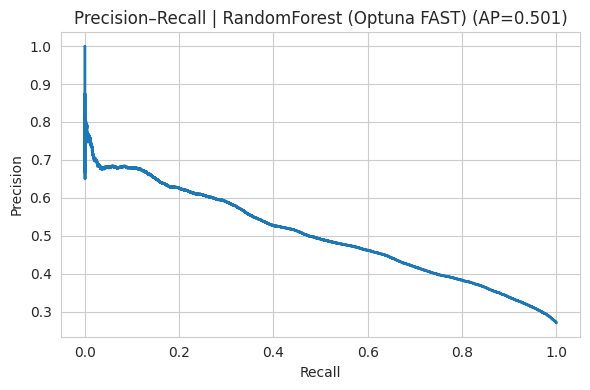

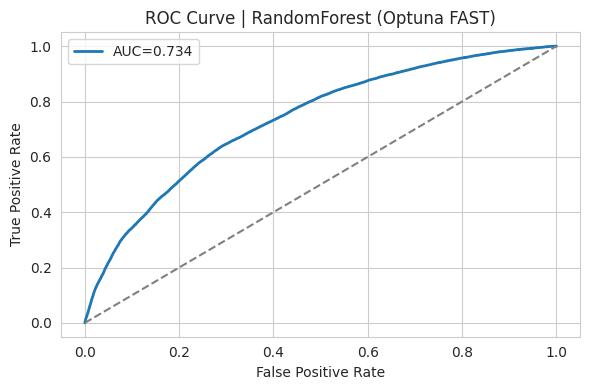

In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

# --- RF: tune on a subsample of numeric-only features ---

optuna_sample_size = 50_000
rng = np.random.RandomState(42)
idx_rf = rng.choice(len(X_tr_num), size=min(optuna_sample_size, len(X_tr_num)), replace=False)

X_opt = X_tr_num.iloc[idx_rf]
y_opt = y_tr[idx_rf]

Xo_tr, Xo_val, yo_tr, yo_val = train_test_split(
    X_opt, y_opt, test_size=0.2, stratify=y_opt, random_state=42
)

def obj_rf_fast(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 300),
        "max_depth": trial.suggest_int("max_depth", 5, 15),
        "min_samples_split": trial.suggest_int("min_samples_split", 5, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 2, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "n_jobs": 4,
        "random_state": 42,
        "class_weight": cw_dict,
    }
    clf = RandomForestClassifier(**params)
    clf.fit(Xo_tr, yo_tr)
    y_val_prob = clf.predict_proba(Xo_val)[:, 1]
    return average_precision_score(yo_val, y_val_prob)

study_rf = optuna.create_study(direction="maximize")
study_rf.optimize(obj_rf_fast, n_trials=10, show_progress_bar=True)

rf_best = RandomForestClassifier(
    **{**study_rf.best_params, "n_jobs": 6, "random_state": 42, "class_weight": cw_dict}
)
rf_best.fit(
    pd.concat([X_tr_num, X_val_num]),
    np.concatenate([y_tr, y_val])
)

y_test_prob_rf = rf_best.predict_proba(X_test_num)[:, 1]
rf_metrics = evaluate_probs(y_test, y_test_prob_rf, label="RandomForest (Optuna FAST)")

  0%|          | 0/20 [00:00<?, ?it/s]

HistGB (Optuna): AUC=0.736 | AP=0.513 | BestF1@0.502 -> P=0.426, R=0.685, F1=0.525


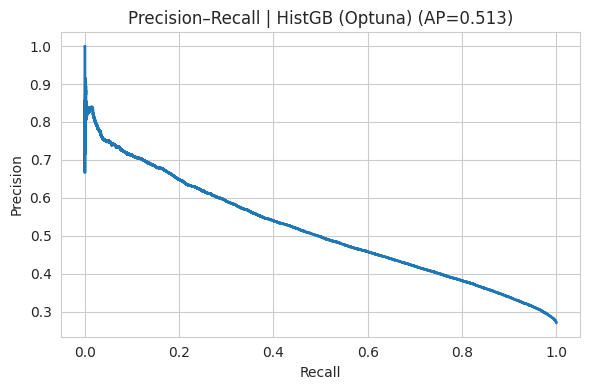

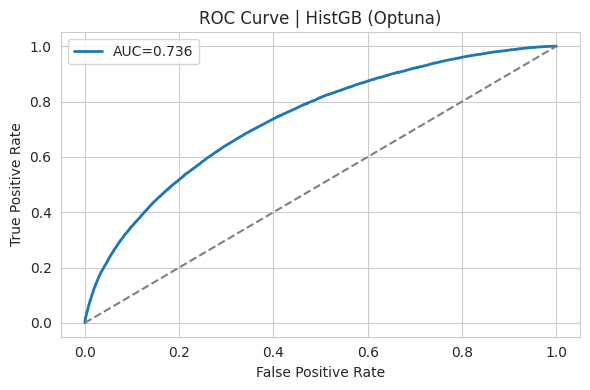

In [ ]:
# --- HistGradientBoosting ---

def obj_hgb(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_iter": trial.suggest_int("max_iter", 150, 600),
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 16, 128),
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "l2_regularization": trial.suggest_float("l2_regularization", 1e-4, 1.0, log=True),
        "random_state": 42,
    }
    w = np.where(y_tr == 1, cw_dict[1], cw_dict[0])
    clf = HistGradientBoostingClassifier(**params)
    clf.fit(X_tr_num, y_tr, sample_weight=w)
    y_val_prob = clf.predict_proba(X_val_num)[:, 1]
    return average_precision_score(y_val, y_val_prob)

study_hgb = optuna.create_study(direction="maximize")
study_hgb.optimize(obj_hgb, n_trials=20, show_progress_bar=True)

hgb_best = HistGradientBoostingClassifier(**{**study_hgb.best_params, "random_state": 42})
w_all = np.where(
    np.concatenate([y_tr, y_val]) == 1,
    cw_dict[1],
    cw_dict[0]
)
hgb_best.fit(
    pd.concat([X_tr_num, X_val_num]),
    np.concatenate([y_tr, y_val]),
    sample_weight=w_all,
)

y_test_prob_hgb = hgb_best.predict_proba(X_test_num)[:, 1]
hgb_metrics = evaluate_probs(y_test, y_test_prob_hgb, label="HistGB (Optuna)")


Running Optuna search (FAST mode) for CatBoost...


  0%|          | 0/8 [00:00<?, ?it/s]

Best CatBoost params: {'iterations': 439, 'depth': 5, 'learning_rate': 0.13112923703115037, 'l2_leaf_reg': 3.7385478779324792}
F1-optimal threshold for CatBoost (val): 0.4072
CatBoost (Optuna FAST, thr=0.407): AUC=0.711 | AP=0.494 | BestF1@0.510 -> P=0.416, R=0.648, F1=0.507


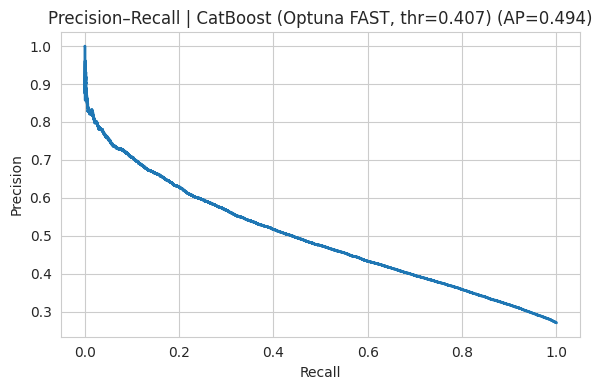

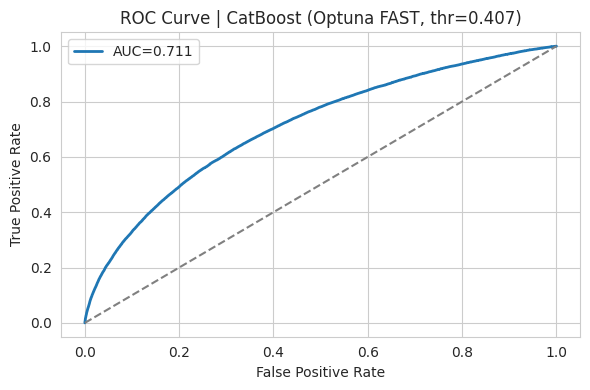

In [ ]:
# --- CatBoost with categoricals ---

try:
    from catboost import CatBoostClassifier, Pool
except ImportError:
    !pip install -q catboost
    from catboost import CatBoostClassifier, Pool

# make sure we have DataFrames
feature_cols = numeric_features + categorical_features

if not hasattr(X_tr_cb, "iloc"):
    X_tr_cb  = pd.DataFrame(X_tr_cb,  columns=feature_cols)
    X_val_cb = pd.DataFrame(X_val_cb, columns=feature_cols)
    X_test_cb = pd.DataFrame(X_test_cb, columns=feature_cols)

Y_TR_IS_SER  = hasattr(y_tr, "iloc")
Y_VAL_IS_SER = hasattr(y_val, "iloc")

rng = np.random.RandomState(42)
SAMPLE_SIZE = 120_000
MAX_ITERS   = 500
EARLY_STOP  = 50
N_TRIALS    = 8

# subsample train for tuning
if len(X_tr_cb) > SAMPLE_SIZE:
    idx = rng.choice(len(X_tr_cb), SAMPLE_SIZE, replace=False)
    X_tr_fast = X_tr_cb.iloc[idx]
    y_tr_fast = y_tr.iloc[idx] if Y_TR_IS_SER else y_tr[idx]
else:
    X_tr_fast, y_tr_fast = X_tr_cb, y_tr

# subsample val
val_cap = min(len(X_val_cb), SAMPLE_SIZE // 4)
if len(X_val_cb) > val_cap:
    idx = rng.choice(len(X_val_cb), val_cap, replace=False)
    X_val_fast = X_val_cb.iloc[idx]
    y_val_fast = y_val.iloc[idx] if Y_VAL_IS_SER else y_val[idx]
else:
    X_val_fast, y_val_fast = X_val_cb, y_val

train_pool_fast = Pool(X_tr_fast, label=y_tr_fast, cat_features=cat_idx)
val_pool_fast   = Pool(X_val_fast,  label=y_val_fast, cat_features=cat_idx)

def obj_cat(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 200, MAX_ITERS),
        "depth": trial.suggest_int("depth", 4, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.15, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "loss_function": "Logloss",
        "eval_metric": "AUC",
        "thread_count": -1,
        "random_seed": 42,
        "verbose": False,
        "class_weights": [cw_dict[0], cw_dict[1]],
    }
    clf = CatBoostClassifier(**params)
    clf.fit(
        train_pool_fast,
        eval_set=val_pool_fast,
        use_best_model=True,
        early_stopping_rounds=EARLY_STOP,
        verbose=False,
    )
    y_val_prob = clf.predict_proba(val_pool_fast)[:, 1]
    return roc_auc_score(y_val_fast, y_val_prob)

print("Running Optuna search (FAST mode) for CatBoost...")
study_cat = optuna.create_study(direction="maximize")
study_cat.optimize(obj_cat, n_trials=N_TRIALS, show_progress_bar=True)
print("Best CatBoost params:", study_cat.best_params)

cat_best = CatBoostClassifier(
    **{
        **study_cat.best_params,
        "loss_function": "Logloss",
        "eval_metric": "AUC",
        "thread_count": -1,
        "random_seed": 42,
        "verbose": False,
        "class_weights": [cw_dict[0], cw_dict[1]],
    }
)

full_X = pd.concat([X_tr_cb, X_val_cb], axis=0)
full_y = np.concatenate([
    y_tr if not Y_TR_IS_SER else y_tr.values,
    y_val if not Y_VAL_IS_SER else y_val.values,
])

full_train_cb = Pool(full_X, label=full_y, cat_features=cat_idx)
cat_best.fit(full_train_cb, early_stopping_rounds=EARLY_STOP, verbose=False)

val_pool_full = Pool(X_val_cb, label=y_val, cat_features=cat_idx)
y_val_prob_full = cat_best.predict_proba(val_pool_full)[:, 1]

prec_cb, rec_cb, thr_cb = precision_recall_curve(y_val, y_val_prob_full)
f1_cb = 2 * (prec_cb * rec_cb) / (prec_cb + rec_cb + 1e-12)
best_idx_cb = np.nanargmax(f1_cb)
best_thr_cb = thr_cb[max(0, best_idx_cb - 1)]
print(f"F1-optimal threshold for CatBoost (val): {best_thr_cb:.4f}")

test_pool = Pool(X_test_cb, label=y_test, cat_features=cat_idx)
y_test_prob_cat = cat_best.predict_proba(test_pool)[:, 1]

cat_metrics = evaluate_probs(
    y_test,
    y_test_prob_cat,
    label=f"CatBoost (Optuna FAST, thr={best_thr_cb:.3f})",
    do_plots=True,
)


### 9.8 Compare models


=== Test Set Summary (sorted by PR-AUC) ===


,Model,ROC-AUC,PR-AUC,Precision,Recall,F1,Best_Threshold
1,HistGB,0.735855,0.513334,0.425721,0.685305,0.525188,0.502104
0,RandomForest,0.733909,0.500925,0.446827,0.642017,0.526927,0.536239
2,CatBoost,0.711207,0.494013,0.415768,0.648048,0.506549,0.510404


Saved best model as best_model_HistGB.pkl


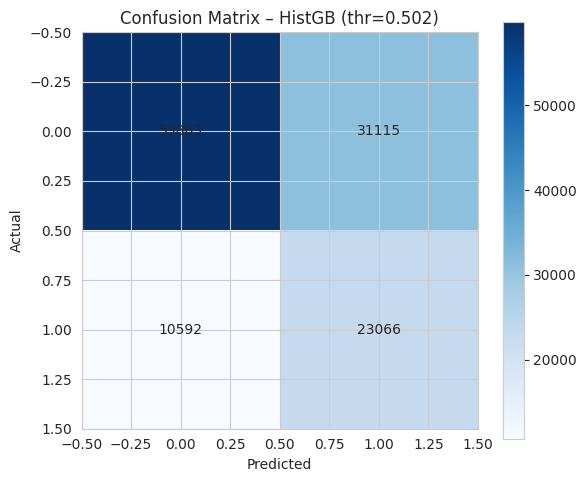


Classification report @best threshold:


In [ ]:
# 9.8 Compare models, choose best, inspect top-k

import joblib
from sklearn.metrics import confusion_matrix, classification_report

def row(name, m):
    return [
        name,
        m["auc"],
        m["ap"],
        m["precision"],
        m["recall"],
        m["f1"],
        m["best_thr"],
    ]

rows = [
    row("RandomForest", rf_metrics),
    row("HistGB", hgb_metrics),
]
if cat_metrics is not None:
    rows.append(row("CatBoost", cat_metrics))

summary_df = pd.DataFrame(
    rows,
    columns=["Model", "ROC-AUC", "PR-AUC", "Precision", "Recall", "F1", "Best_Threshold"],
).sort_values("PR-AUC", ascending=False)

print("\n=== Test Set Summary (sorted by PR-AUC) ===")
display(summary_df)

# pick best
best_name = summary_df.iloc[0]["Model"]
if best_name == "CatBoost":
    best_model, best_probs = cat_best, y_test_prob_cat
elif best_name == "HistGB":
    best_model, best_probs = hgb_best, y_test_prob_hgb
else:
    best_model, best_probs = rf_best, y_test_prob_rf

joblib.dump(best_model, f"best_model_{best_name}.pkl")
print(f"Saved best model as best_model_{best_name}.pkl")

best_thr = float(summary_df.iloc[0]["Best_Threshold"])
y_pred_best = (best_probs >= best_thr).astype(int)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
plt.title(f"Confusion Matrix – {best_name} (thr={best_thr:.3f})")
plt.imshow(cm, cmap="Blues")
for (i, j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha="center", va="center")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.tight_layout()
plt.show()

print("\nClassification report @best threshold:")



In [ ]:
print(classification_report(y_test, y_pred_best, digits=3))

              precision    recall  f1-score   support

           0      0.850     0.658     0.742     90978
           1      0.426     0.685     0.525     33658

    accuracy                          0.665    124636
   macro avg      0.638     0.672     0.633    124636
weighted avg      0.735     0.665     0.683    124636



In [ ]:
# Top-k precision helper

def topk_precision(y_true, y_prob, ks=(0.01, 0.05, 0.10)):
    n = len(y_true)
    out = []
    order = np.argsort(-y_prob)
    for k in ks:
        m = max(1, int(n * k))
        top_idx = order[:m]
        prec = y_true[top_idx].mean()
        out.append((f"Top {int(k*100)}%", prec))
    return pd.DataFrame(out, columns=["Slice", "Precision"])

print("Baseline prevalence (test):", y_test.mean().round(4))
tk = topk_precision(y_test, best_probs, ks=(0.01, 0.05, 0.10))
display(tk)


Baseline prevalence (test): 0.2701


,Slice,Precision
0,Top 1%,0.781701
1,Top 5%,0.696196
2,Top 10%,0.629142


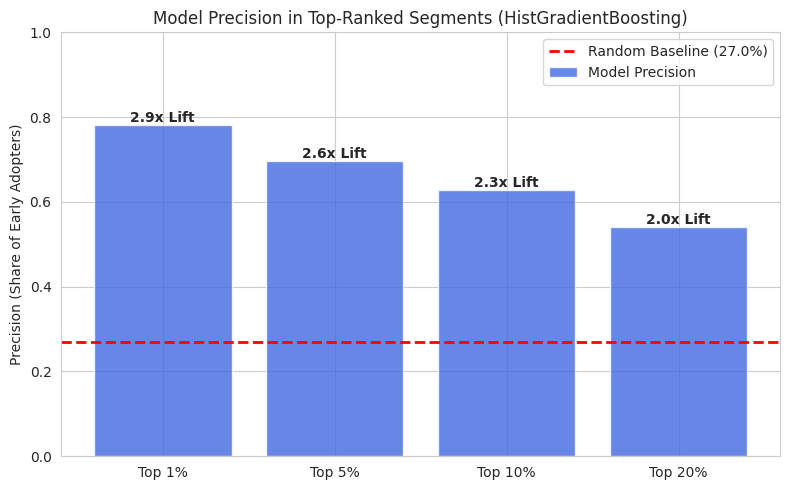

In [ ]:


# Ensure we have the best probabilities and labels
# (Assuming you ran the model selection code in 9.8)
y_true = y_test
y_prob = best_probs  # This is the probability from your best model (HistGB)
baseline = y_true.mean()

# Calculate Precision at k
ks = [0.01, 0.05, 0.10, 0.20]
data = []
order = np.argsort(-y_prob)
n = len(y_true)

for k in ks:
    m = int(n * k)
    top_idx = order[:m]
    prec = y_true[top_idx].mean()
    lift = prec / baseline
    data.append({
        "Percentile": f"Top {int(k*100)}%",
        "Precision": prec,
        "Lift": lift
    })

df_topk = pd.DataFrame(data)

# Plotting
fig, ax1 = plt.figure(figsize=(8, 5)), plt.gca()
bars = ax1.bar(df_topk["Percentile"], df_topk["Precision"], color="royalblue", alpha=0.8, label="Model Precision")
ax1.axhline(baseline, color="red", linestyle="--", linewidth=2, label=f"Random Baseline ({baseline:.1%})")

# Add Lift labels on top of bars
for bar, lift in zip(bars, df_topk["Lift"]):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f"{lift:.1f}x Lift",
             ha='center', va='bottom', fontweight='bold')

ax1.set_ylabel("Precision (Share of Early Adopters)")
ax1.set_title("Model Precision in Top-Ranked Segments (HistGradientBoosting)")
ax1.set_ylim(0, 1.0)
ax1.legend()
plt.tight_layout()
plt.show()

### 9.9 Business-facing slices from best model (optional quick view)

In [ ]:
if best_name == "CatBoost":
    df_scores = test_df[[*id_cols, *categorical_features]].copy()
    df_scores["pred_prob"] = y_test_prob_cat
else:
    df_scores = test_df[[*id_cols, *categorical_features]].copy()
    df_scores["pred_prob"] = (
        y_test_prob_hgb if best_name == "HistGB" else y_test_prob_rf
    )

print("\nTop specialties by predicted early adoption (mean prob):")
display(
    df_scores.groupby("Prscrbr_Type")["pred_prob"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop states by predicted early adoption (mean prob):")
display(
    df_scores.groupby("Prscrbr_State_Abrvtn")["pred_prob"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)


Top specialties by predicted early adoption (mean prob):


/tmp/ipykernel_2967/271407072.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_scores.groupby("Prscrbr_Type")["pred_prob"]


Prscrbr_Type
Maxillofacial Surgery                      0.717508
General Acute Care Hospital                0.714030
Pain Medicine                              0.673021
Psychologist                               0.671099
Emergency Medical Technician, Paramedic    0.586807
Legal Medicine                             0.557543
Surgery                                    0.523419
General Practice                           0.519951
Registered Nurse                           0.519470
Sports Medicine                            0.518009
Name: pred_prob, dtype: float64


Top states by predicted early adoption (mean prob):


/tmp/ipykernel_2967/271407072.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_scores.groupby("Prscrbr_State_Abrvtn")["pred_prob"]


Prscrbr_State_Abrvtn
ZZ    0.747508
VI    0.598189
MP    0.485640
WV    0.482647
PR    0.481642
MO    0.481201
DE    0.480393
NJ    0.479220
OK    0.477665
AL    0.477625
Name: pred_prob, dtype: float64

## **10. Model Explainability and Interpretation**

/tmp/ipykernel_2967/4201517207.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_cb, plot_type="bar", show=False)


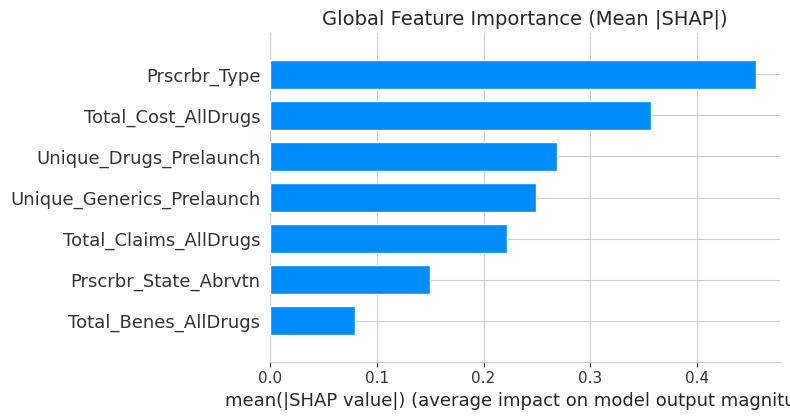

In [ ]:

    explainer = shap.TreeExplainer(cat_best)
    shap_values = explainer.shap_values(X_test_cb)


    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test_cb, plot_type="bar", show=False)
    plt.title("Global Feature Importance (Mean |SHAP|)", fontsize=14)
    plt.tight_layout()

    plt.show()


## **11. Business Insights & Recommendations**

For full business interpretation, recommendations, limitations, and future work,
please refer to Chapters 7 and 8 of the thesis

 ## **12. Reproducibility & Export**

In [ ]:
import os, joblib, pandas as pd, numpy as np

export_dir = "exports"
os.makedirs(export_dir, exist_ok=True)

# --- Save best classical model (CatBoost) ---
joblib.dump(cat_best, f"{export_dir}/catboost_model.pkl")

# --- Save optional deep model (if used) ---
if "wide_deep" in locals():
    import tensorflow as tf  # only needed here
    wide_deep.save(f"{export_dir}/wide_deep_model.keras")

# --- Save metrics for comparison ---
metrics_list = []
if "rf_metrics" in locals():
    metrics_list.append(rf_metrics | {"Model": "RandomForest"})
if "hgb_metrics" in locals():
    metrics_list.append(hgb_metrics | {"Model": "HistGB"})
if "cat_metrics" in locals():
    metrics_list.append(cat_metrics | {"Model": "CatBoost"})

if metrics_list:
    metrics = pd.DataFrame(metrics_list)
    metrics.to_csv(f"{export_dir}/all_model_metrics.csv", index=False)

# --- Save predictions (Power BI) ---
preds = pd.DataFrame({
    "Prscrbr_NPI": test_df["Prscrbr_NPI"].values,
    "Brnd_Name": test_df["Brnd_Name"].values,
    "Prscrbr_Type": test_df["Prscrbr_Type"].values,
    "Prscrbr_State_Abrvtn": test_df["Prscrbr_State_Abrvtn"].values,
    "CatBoost_Prob": (
        y_test_prob_cat if "y_test_prob_cat" in locals()
        else np.full(len(test_df), np.nan)
    ),
})
preds.to_csv(f"{export_dir}/predictions_powerbi.csv", index=False)

# --- Save processed dataframes ---

# model_df usually has only standard dtypes, but we can save it directly:
model_df.to_parquet(f"{export_dir}/model_df.parquet", compression="snappy")

# df may contain Interval or categorical-of-Interval columns -> convert them to string
df_export = df.copy()

from pandas.api.types import CategoricalDtype, IntervalDtype

for col in df_export.columns:
    dtype = df_export[col].dtype
    # pure Interval
    if isinstance(dtype, pd.IntervalDtype):
        df_export[col] = df_export[col].astype("string")
    # categorical whose categories are Intervals
    elif isinstance(dtype, pd.CategoricalDtype) and isinstance(
        df_export[col].cat.categories.dtype, pd.IntervalDtype
    ):
        df_export[col] = df_export[col].astype("string")

df_export.to_parquet(f"{export_dir}/full_df.parquet", compression="snappy")

print(f"All models, metrics, and predictions exported to: {os.path.abspath(export_dir)}")


All models, metrics, and predictions exported to: /teamspace/studios/this_studio/exports


## **References**

OpenAI. (2025). ChatGPT was used throughout the project to refine language, debug code, and guide the structure this notebook.
https://chatgpt.com/share/6934107c-2f64-8008-b95c-0a370e16b1ec